In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Parameter

In [2]:
mu_m = 0.9       # 1/h
K_S = 0.21       # g/L
K_I = 1.5        # g/L
Y_XS = 0.6       # g/g
K_CL = 0.2       # mg/L
Y_OS = 160.0     # mg/g
M = 0.0314       # Eq. constante
V_L = 90.0       # L
eps = 0.2        # Fraction de rétention de gaz
V_G = eps * V_L  # L
G = 5000.0       # L/h
C_Li_in = 6.0    # mg/L
C_Gi_in = 250.0  # mg/L

Equations

In [3]:
y0_default = [1.0, 0.0, 6.0, 250.0] # [X, S, C_L, C_G]

def get_mu(S, C_L):
    S = max(0.0, S)
    C_L = max(0.0, C_L)
    
    # Haldane equation
    mu_S = S / (K_S + S + (S**2)/K_I)
    mu_O2 = C_L / (K_CL + C_L)
    return mu_m * mu_S * mu_O2

def fermenter_odes(t, y, F, KLa, Si):
    X, S, C_L, C_G = y
    
    mu = get_mu(S, C_L)
    C_L_star = M * C_G
    
    # Mass balances
    dX_dt = -(F/V_L)*X + mu*X
    dS_dt = (F/V_L)*(Si - S) - (1/Y_XS)*mu*X
    dCL_dt = (F/V_L)*(C_Li_in - C_L) - (Y_OS/Y_XS)*mu*X + KLa*(C_L_star - C_L)
    dCG_dt = (G/V_G)*(C_Gi_in - C_G) - KLa*(V_L/V_G)*(C_L_star - C_L)
    
    return [dX_dt, dS_dt, dCL_dt, dCG_dt]

def calc_OUR(mu_array, X_array):
    return (Y_OS / Y_XS) * mu_array * X_array * V_L

Part A : 

<function matplotlib.pyplot.show(close=None, block=None)>

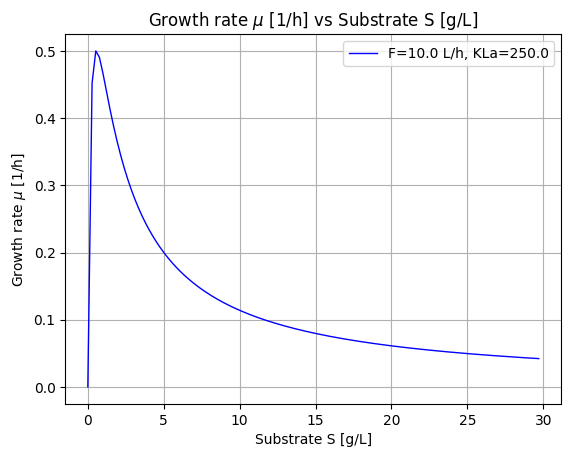

In [4]:
F_a = 10.0
KLa_a = 250.0
Si_a = 30.0

sol_a = solve_ivp(fermenter_odes, [0, 50], y0_default, method='BDF', 
                  args=(F_a, KLa_a, Si_a), rtol=1e-6, atol=1e-6, dense_output=True)

t_a = np.linspace(0, 50, 500)
y_a = sol_a.sol(t_a)
mu_a = np.array([get_mu(y_a[1, i], y_a[2, i]) for i in range(len(t_a))])

plt.plot(y_a[1, :], mu_a, color='blue', linewidth=1.0, label=f'F={F_a} L/h, KLa={KLa_a}')
plt.title('Growth rate $\mu$ [1/h] vs Substrate S [g/L]')
plt.xlabel('Substrate S [g/L]')
plt.ylabel('Growth rate $\mu$ [1/h]')
plt.grid(True)
plt.legend()
plt.show

Part B : 

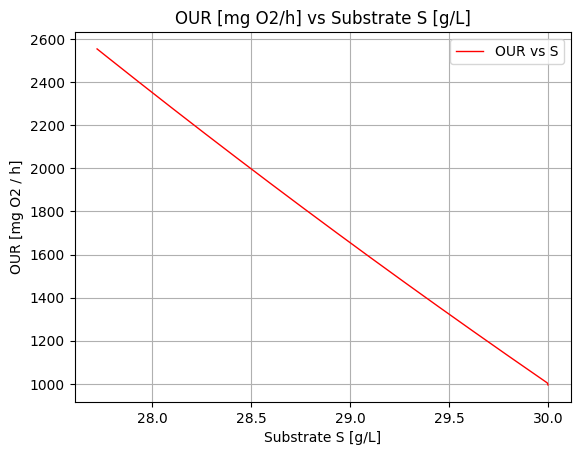

In [5]:
F_b = 0.0
KLa_b = 70.0
Si_b = 30.0
y0_batch = [1.0, 30.0, 6.0, 250.0] # S(0) = 30 g/L

sol_bc = solve_ivp(fermenter_odes, [0, 20], y0_batch, method='BDF', 
                   args=(F_b, KLa_b, Si_b), rtol=1e-6, atol=1e-6, dense_output=True)

t_bc = np.linspace(0, 20, 500)
y_bc = sol_bc.sol(t_bc)
X_bc, S_bc, CL_bc, CG_bc = y_bc

mu_bc = np.array([get_mu(S_bc[i], CL_bc[i]) for i in range(len(t_bc))])
OUR_bc = calc_OUR(mu_bc, X_bc)
plt.plot(S_bc, OUR_bc, label='OUR vs S', linewidth=1.0, color='red')
plt.title('OUR [mg O2/h] vs Substrate S [g/L]')
plt.xlabel('Substrate S [g/L]')
plt.ylabel('OUR [mg O2 / h]')
plt.grid(True)
plt.legend()

Part C :

/var/folders/9p/ykx729_d78s7c9561km5tbfm0000gn/T/ipykernel_11852/615737701.py:4: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "--" (-> linestyle='--'). The keyword argument will take precedence.
  plt.plot(t_bc, OUR_meas, linestyle=(0, (5, 5)), label='Measured OUR (Gas)',linewidth=1.0, color='red')


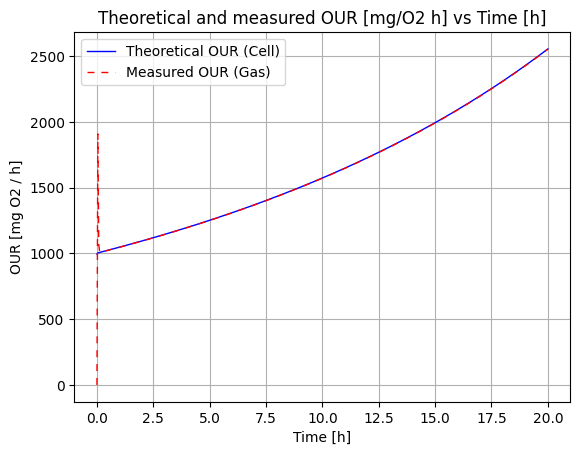

In [6]:
OUR_meas = G * (C_Gi_in - CG_bc)

plt.plot(t_bc, OUR_bc, label='Theoretical OUR (Cell)',linewidth=1.0, color='blue')
plt.plot(t_bc, OUR_meas, linestyle=(0, (5, 5)), label='Measured OUR (Gas)',linewidth=1.0, color='red')
plt.title('Theoretical and measured OUR [mg/O2 h] vs Time [h]')
plt.xlabel('Time [h]')
plt.ylabel('OUR [mg O2 / h]')
plt.grid(True)
plt.legend()

Part D :

<function matplotlib.pyplot.show(close=None, block=None)>

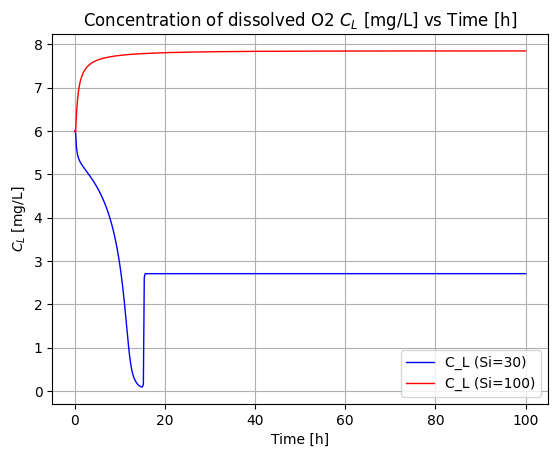

In [7]:
F_d = 6.5
KLa_d = 70.0

sol_d_30 = solve_ivp(fermenter_odes, [0, 100], y0_default, method='BDF', 
                     args=(F_d, KLa_d, 30.0), rtol=1e-6, atol=1e-6, dense_output=True)
sol_d_100 = solve_ivp(fermenter_odes, [0, 100], y0_default, method='BDF', 
                      args=(F_d, KLa_d, 100.0), rtol=1e-6, atol=1e-6, dense_output=True)

t_d = np.linspace(0, 100, 500)
y_d_30 = sol_d_30.sol(t_d)
y_d_100 = sol_d_100.sol(t_d)

plt.plot(t_d, y_d_30[2, :], label='C_L (Si=30)', linewidth=1.0,color='blue')
plt.plot(t_d, y_d_100[2, :], label='C_L (Si=100)', linewidth=1.0, color='red')
plt.title('Concentration of dissolved O2 $C_L$ [mg/L] vs Time [h]')
plt.xlabel('Time [h]')
plt.ylabel('$C_L$ [mg/L]')
plt.grid(True)
plt.legend()
plt.show